## Klasifikasi Citra Satelit

Pada praktikum ini digunakan dataset UC Merced. Dataset ini merupakan salah satu dataset citra satelit paling awal dalam bidang computer vision dan sering disebut sebagai “MNIST” untuk citra satelit, karena perannya sebagai dataset standar untuk pelatihan dan pengujian model Convolutional Neural Network (CNN).

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## Dataset

In [ ]:
!pip install wget   #wget digunakan untuk mendowload file

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=31f9f4188f0174461f9e6125b4ecb756e9c08ee0b6995bbf583a7b90bc19600a
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
import wget  #mendownload dataset

url = 'https://mymldatasets.s3.eu-de.cloud-object-storage.appdomain.cloud/UCMerced_LandUse.zip'
wget.download(url)

'UCMerced_LandUse.zip'

In [ ]:
#mengekstrak file dataset
import zipfile
with zipfile.ZipFile('UCMerced_LandUse.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [ ]:
#membuat label beradasarkan nama-nama folder citra di folder dataset (cek di bagian Files di sidebar/menu samping)
import os
from pathlib import Path

PATH = Path('dataset/Images')

labels = os.listdir(PATH)
labels, len(labels)

(['intersection',
  'harbor',
  'overpass',
  'denseresidential',
  'mobilehomepark',
  'buildings',
  'mediumresidential',
  'golfcourse',
  'forest',
  'airplane',
  'runway',
  'freeway',
  'parkinglot',
  'baseballdiamond',
  'sparseresidential',
  'chaparral',
  'storagetanks',
  'tenniscourt',
  'agricultural',
  'river',
  'beach'],
 21)

In [ ]:
#mencetak masing masing jumlah citra dalam setiap folder
for label in labels:
    items = os.listdir(PATH/label)
    print(label, ':', len(items))

intersection : 100
harbor : 100
overpass : 100
denseresidential : 100
mobilehomepark : 100
buildings : 100
mediumresidential : 100
golfcourse : 100
forest : 100
airplane : 100
runway : 100
freeway : 100
parkinglot : 100
baseballdiamond : 100
sparseresidential : 100
chaparral : 100
storagetanks : 100
tenniscourt : 100
agricultural : 100
river : 100
beach : 100


In [ ]:
#membuat tabel nama citra dan labelnya
import pandas as pd

img_paths, cls = [], []
for i, label in enumerate(labels):
    names = os.listdir(PATH/label)
    img_paths += [PATH/label/name for name in names]
    cls += [i for name in names]

df = pd.DataFrame({'img': img_paths, 'label': cls})
df.sample(5)

,img,label
2013,dataset/Images/beach/beach60.tif,20
886,dataset/Images/forest/forest35.tif,8
300,dataset/Images/denseresidential/denseresidenti...,3
1825,dataset/Images/agricultural/agricultural69.tif,18
1720,dataset/Images/tenniscourt/tenniscourt93.tif,17


In [ ]:
len(df)

2100

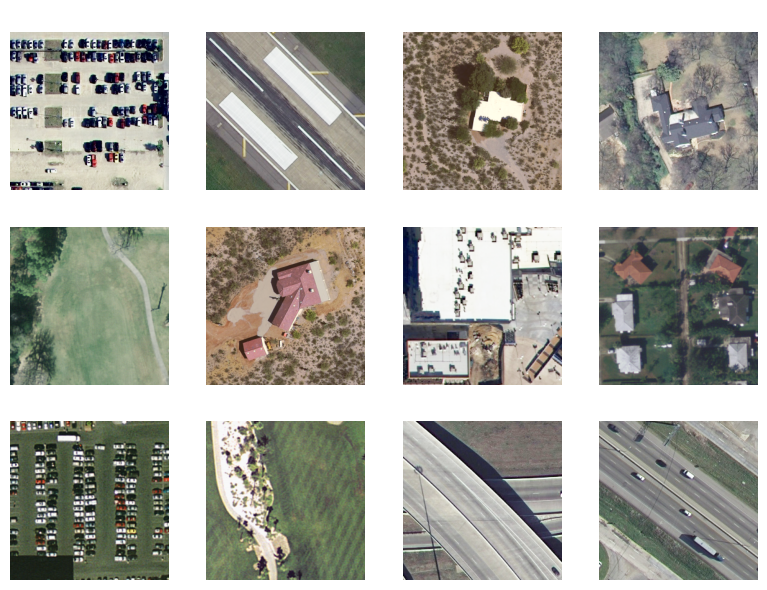

In [ ]:
#menampilkan sample gambar dari dataset

import matplotlib.pyplot as plt
from skimage import io
import random

r, c = 3, 4
fig = plt.figure(figsize=(2*c, 2*r))
for _r in range(r):
    for _c in range(c):
        ax = plt.subplot(r, c, _r*c + _c + 1)
        ix = random.randint(0, len(df)-1)
        img_path, label = df['img'][ix], df['label'][ix]
        img = io.imread(img_path)
        plt.imshow(img)
        plt.title(labels[label], color="white")
        plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#membuat split dataset 80/20  (test_size = 0,2)

from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.2, shuffle=True)
len(train_df), len(val_df)

(1680, 420)

In [ ]:
#Membuat class dataset dari gambar dan label yang sudah ada
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, imgs, labels, trans):
        self.imgs = imgs
        self.labels = labels
        self.trans = trans

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, ix):
        img = io.imread(self.imgs[ix])
        label = self.labels[ix]
        img = self.trans(image=img)['image']
        return torch.from_numpy(img / 255.).permute(2,0,1).float(), torch.tensor(label).long()

### Augmentasi citra
Proses memperbanyak variasi data gambar secara artifisial dengan cara memodifikasi citra asli
disini menggunakan Resize dan membalik secara verical

In [ ]:
import albumentations as A

trans = A.Compose([
    A.Resize(224,224),
    A.VerticalFlip(p=0.5)
])

dataset = {
    'train': Dataset(train_df['img'].values, train_df['label'].values, trans),
    'val': Dataset(val_df['img'].values, val_df['label'].values, trans)
}

len(dataset['train']), len(dataset['val'])

(1680, 420)

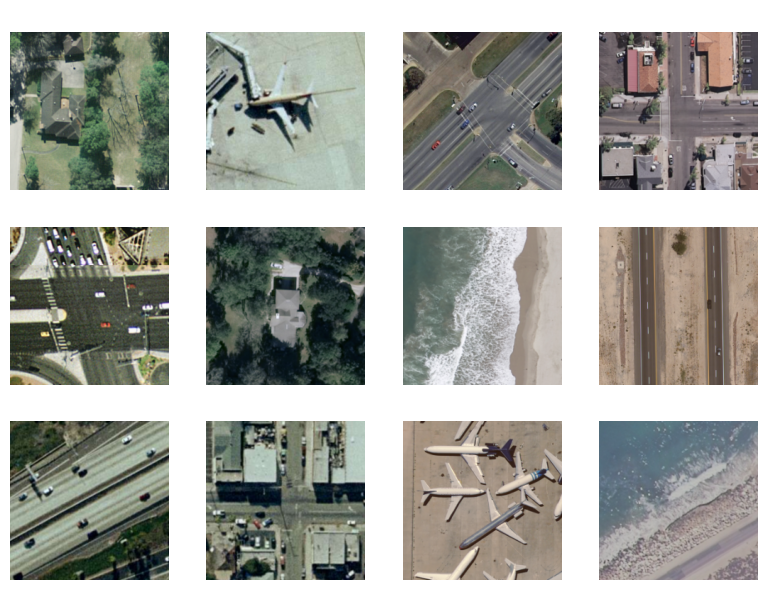

In [ ]:
r, c = 3, 4
fig = plt.figure(figsize=(2*c, 2*r))
for _r in range(r):
    for _c in range(c):
        ax = plt.subplot(r, c, _r*c + _c + 1)
        ix = random.randint(0, len(dataset['train'])-1)
        img, label = dataset['train'][ix]
        plt.imshow(img.permute(1,2,0))
        plt.title(labels[label.item()], color="white")
        plt.axis("off")
plt.tight_layout()
plt.show()

## Model CNN
Lengkapi kode berikut, pilih salah satu model CNN

In [ ]:
import torchvision

class Model(torch.nn.Module):
    def __init__(self, labels):
      super().__init__()
      self.labels = labels
      self.densenet = torchvision.models.densenet121(pretrained=True)
      self.densenet.classifier = torch.nn.Linear(self.densenet.classifier.in_features, len(labels))
    def forward(self, x):
      return self.densenet(x)

In [ ]:
model = Model(labels)
model


Model(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1,

## Pelatihan model
Lengkapi kode untuk pelatihan model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
train_loader = DataLoader(dataset['train'], batch_size=32, shuffle=True)
val_loader = DataLoader(dataset['val'], batch_size=32, shuffle=False)

In [ ]:
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Model(
  (densenet): DenseNet(
    (features): Sequential(
      (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1,

In [ ]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_loss = running_loss / len(dataset['train'])
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

    # Validation loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f"Validation Accuracy: {accuracy:.2f}%")

print("Finished Training")

Epoch 1/10, Loss: 0.9704
Validation Accuracy: 78.57%
Epoch 2/10, Loss: 0.3983
Validation Accuracy: 87.86%
Epoch 3/10, Loss: 0.2665
Validation Accuracy: 85.24%
Epoch 4/10, Loss: 0.2103
Validation Accuracy: 88.57%
Epoch 5/10, Loss: 0.1629
Validation Accuracy: 89.05%
Epoch 6/10, Loss: 0.2077
Validation Accuracy: 82.86%
Epoch 7/10, Loss: 0.1681
Validation Accuracy: 90.71%
Epoch 8/10, Loss: 0.2021
Validation Accuracy: 90.24%
Epoch 9/10, Loss: 0.1030
Validation Accuracy: 93.57%
Epoch 10/10, Loss: 0.1308
Validation Accuracy: 90.71%
Finished Training


## Evaluasi
Lengkapi kode untuk evaluasi/testing model

In [ ]:
# Evaluate the model on the validation set
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy of the model on the {total} validation images: {accuracy:.2f}%')

Accuracy of the model on the 420 validation images: 90.71%


## Menyimpan dan memuat (load) model

In [ ]:
torch.jit.save(torch.jit.script(model.cpu()), 'model.zip')   #menyimpan model yang sudah dilatih

In [ ]:
model = torch.jit.load('model.zip')   #memuat model yang sudah disimpan